In [4]:
import pandas as pd
xl_file = "/data/blue_fin_antartica/BallenyIslands2015/annotation_metadata_Baleeny2015_HC03_FINAL.xlsx"
sheets = pd.ExcelFile(xl_file).sheet_names
print(sheets)
df = pd.read_excel(xl_file, sheet_name=sheets[0])

['BaleenyHC032015']


/home/noah/embed_venv/lib/python3.11/site-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: BaleenyHC032015!$A:$AO.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


In [5]:
df.columns

Index(['File #', 'Name', 'wavFileName', 'StartTime', 'StopTime', 'Analyst',
       'DateAnalysed', 'NoiseIntensity', 'NoiseSources',
       'Chorus (band energy Antblue = Antartic blue whale band, fin = fin whale band)',
       'Bm Ant-A', 'BmAcorrectHrs', 'Bm Ant-B', 'BmAntBcorrectHrs', 'Bm Ant-Z',
       'BmAntZcorrect', 'BlueD', 'BlueDcorrect', 'Bp  Downsweep',
       'BpDownCorrect', 'Bp 20Hz', 'Unnamed: 21', 'Bp Higher_calls',
       'BpHighCorrect', 'Bp20Higher', 'Bp20HigherCorrect', 'MinkeDownsweep',
       'minkeCorrect', 'MinkeBioDuck', 'Sei', 'Humpback', 'humpCorrect',
       'Unidentified', 'uNidcORRECT', 'UnidDetails', 'Pinniped', 'Seismic',
       'Ice', 'Floor/ceiling dB', 'Window (Hz, sec)',
       'Window size (samples, overlap, hop size)', 'Notes_1', 'Note 2'],
      dtype='object')

In [6]:
import warnings
from pathlib import Path

data_root = Path("/data/blue_fin_antartica")
xl_files = sorted(
    p for p in data_root.rglob("*")
    if p.suffix.lower() in {".xlsx", ".xlsm", ".xls"} and not p.name.startswith((".", "~$"))
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    for p in xl_files:
        sheets = pd.ExcelFile(p).sheet_names
        flag = "" if len(sheets) == 1 else "  <-- MULTIPLE SHEETS"
        print(f"{p.relative_to(data_root)}: {sheets}{flag}")

01-Documentation/annotation_metadata_template.xlsx: ['Sheet1']
BallenyIslands2015/annotation_metadata_Baleeny2015_HC03_FINAL.xlsx: ['BaleenyHC032015']
ElephantIsland2013Aural/AWI2013_AU0231_Balcazar_31072019.xlsx: ['AWI251-01_AU0231_sub_effort']
ElephantIsland2014/annotation_metadata_Elephant_Island_EL.xlsx: ['Sheet1']
Greenwich64S2015/AWI2015_subsample_Balcazar.xlsx: ['kerguelen2015_subsample_effort']
MaudRise2014/MaudRise2014_RavenAnnotations_SORP_Library/maudRise_subsample_Miller.xlsx: ['MaudRise2014_SORP_Subsample']
MaudRise2014/maudRise_subsample_Miller.xlsx: ['MaudRise2014_SORP_Subsample']
RossSea2014/20140209_110000.unid.selectionsWITHCOMMENTS.xlsx: ['20140209_110000.unidwithcomment']
RossSea2014/annotation_metadata_Ross2014_SLN_FINAL.xlsx: ['Ross2014', 'Casey', 'Kerguelen', 'SoundTypes']  <-- MULTIPLE SHEETS
casey2014/casey2014_annotation_metadata_NB.xlsx: ['Casey', 'Casey_1', 'Casey_2']  <-- MULTIPLE SHEETS
casey2017/Annotated library/annotation_metadata_casey2017.xlsx: ['case

In [7]:
annot_df = "/home/noah/HALLO_encoder_collection/data_raw/blue_fin_antartica/20261007_104040/annotations.csv"

annot_df = pd.read_csv(annot_df)
annot_df.columns

/tmp/ipykernel_1978190/2272920422.py:3: DtypeWarning: Columns (5,7,12,15,25) have mixed types. Specify dtype option on import or set low_memory=False.
  annot_df = pd.read_csv(annot_df)


Index(['Soundfile', 'Dataset', 'LowFreqHz', 'HighFreqHz', 'FileEndSec', 'UTC',
       'FileBeginSec', 'ClassSpecies', 'KW', 'KW_certain', 'Ecotype',
       'Provider', 'AnnotationLevel', 'FilePath', 'FileOk', 'CallType',
       'CalltypeCategory', 'HasQ', 'CalltypeHasQ', 'LocalPath', 'LocalFileOk',
       'CenterTime', 'Duration', 'EcotypeCertain', 'Labels',
       'BackgroundMethod', 'uid'],
      dtype='object')

In [8]:
annot_df['Labels'].value_counts()

Labels
Background    1308397
BlueWhale       49101
UndBio          31146
FinWhale        27472
MinkeWhale       1495
HW                208
Name: count, dtype: int64

In [9]:
# freq range (annotation box LowFreqHz -> HighFreqHz) per label; Background windows have no box
events = annot_df[annot_df["Labels"] != "Background"].copy()
events["BandwidthHz"] = events["HighFreqHz"] - events["LowFreqHz"]

def freq_summary(grouped):
    return pd.DataFrame({
        "n": grouped.size(),
        "low_p05": grouped["LowFreqHz"].quantile(0.05),
        "low_median": grouped["LowFreqHz"].median(),
        "high_median": grouped["HighFreqHz"].median(),
        "high_p95": grouped["HighFreqHz"].quantile(0.95),
        "high_max": grouped["HighFreqHz"].max(),
        "bandwidth_median": grouped["BandwidthHz"].median(),
    }).round(1)

freq_summary(events.groupby("Labels"))

,n,low_p05,low_median,high_median,high_p95,high_max,bandwidth_median
Labels,,,,,,,
BlueWhale,49101,15.3,24.1,28.3,97.1,125.0,6.4
FinWhale,27472,12.8,15.4,62.8,100.8,137.5,19.5
HW,208,11.7,33.0,121.8,217.7,484.4,81.6
MinkeWhale,1495,57.5,96.6,123.9,168.8,347.2,28.5
UndBio,31146,15.0,57.0,104.2,125.0,1024.0,29.5


In [10]:
# same, split by call type (labels like BlueWhale / FinWhale mix narrow tonal calls and wide downsweeps)
by_calltype = freq_summary(events.groupby(["Labels", events["CallType"].fillna("(none)")]))
by_calltype

n  low_p05  low_median  high_median  \
Labels     CallType                                                        
BlueWhale  Ant-A                 24347     22.4        23.9         27.7   
           Ant-B                  6890     13.5        16.4         28.0   
           Ant-Z                  2512     14.3        15.8         28.2   
           D                     15337     33.2        49.7         80.9   
           SWI                      15     27.4        33.2         39.2   
FinWhale   20Hz                  12931     12.8        15.1         28.6   
           20Plus                 7759     12.3        14.8         91.3   
           Backbeat                230     11.1        12.0         14.3   
           Downsweep              6379     34.8        50.3         79.0   
           HigherCall              173     11.7        14.6         83.3   
HW         (none)                  208     11.7        33.0        121.8   
MinkeWhale (none)                   40     86.7        95.9        180.2   
           Bioduck                  14     60.6       100.7        124.5   
           BioduckAndDownsweeps     71     70.2        93.0        159.6   
           Downsweep              1370     56.9        96.7        123.8   
UndBio     (none)                28935     14.8        54.7        100.2   
           RecurrentPulses        1963     44.8        95.1        121.2   
           SWI                       1     31.1        31.1         38.2   
           Tonal30Hz               247     13.8        20.0         30.4   

                                 high_p95  high_max  bandwidth_median  
Labels     CallType                                                    
BlueWhale  Ant-A                     29.1     110.6               3.9  
           Ant-B                     29.4      99.0              11.7  
           Ant-Z                     29.5      34.6              12.5  
           D                        109.3     125.0              30.3  
           SWI                       48.5      63.7               5.3  
FinWhale   20Hz                      33.6      47.9              13.4  
           20Plus                   101.6     112.7              77.5  
           Backbeat                  14.8      15.5               2.3  
           Downsweep                108.5     137.5              27.2  
           HigherCall                85.4      86.7              68.5  
HW         (none)                   217.7     484.4              81.6  
MinkeWhale (none)                   255.4     268.0              90.1  
           Bioduck                  125.0     125.0              23.8  
           BioduckAndDownsweeps     301.8     347.2              65.6  
           Downsweep                136.7     206.1              27.4  
UndBio     (none)                   125.0    1024.0              30.4  
           RecurrentPulses          123.8     124.7              26.2  
           SWI                       38.2      38.2               7.1  
           Tonal30Hz                 31.1      31.1               9.5

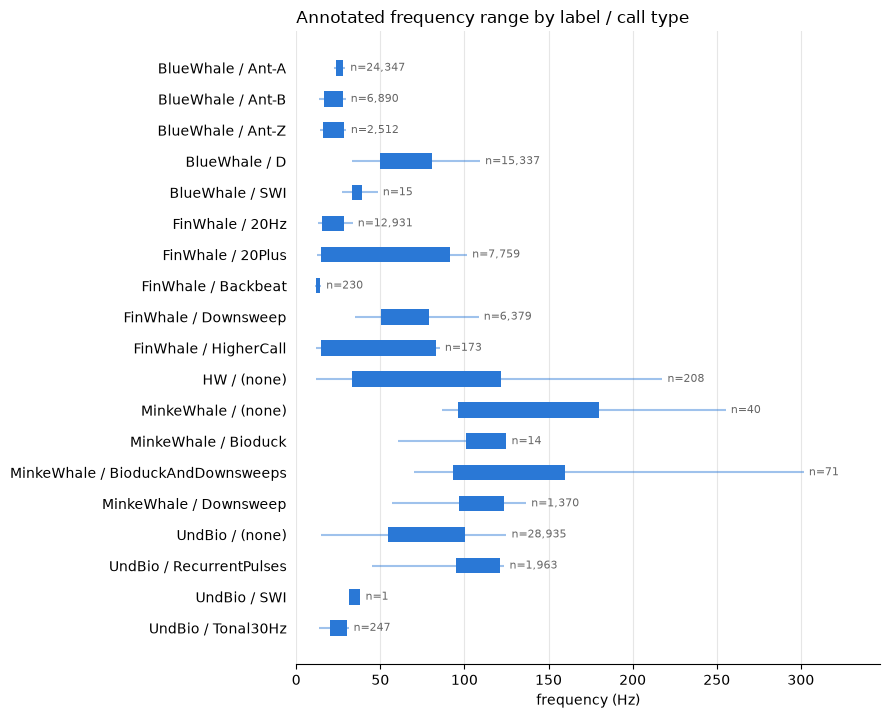

In [11]:
import matplotlib.pyplot as plt

# thick bar: median low -> median high; thin line: 5th pct of low -> 95th pct of high
fig, ax = plt.subplots(figsize=(9, 0.32 * len(by_calltype) + 1.2))
rows = by_calltype.iloc[::-1]
names = [f"{label} / {calltype}" for label, calltype in rows.index]
ax.hlines(names, rows["low_p05"], rows["high_p95"], color="#2a78d6", linewidth=1.5, alpha=0.45)
ax.barh(names, rows["high_median"] - rows["low_median"], left=rows["low_median"], height=0.5, color="#2a78d6")
for name, n, x in zip(names, rows["n"], rows["high_p95"]):
    ax.text(x + 3, name, f"n={n:,}", va="center", fontsize=8, color="0.4")
ax.set_xlim(0, rows["high_p95"].max() * 1.15)
ax.set_xlabel("frequency (Hz)")
ax.set_title("Annotated frequency range by label / call type", loc="left")
ax.grid(axis="x", color="0.9"); ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False); ax.tick_params(left=False)
plt.tight_layout()